In [19]:
import io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

plt.style.use('seaborn-v0_8-whitegrid')

## Dataset Iris

Dataset Iris diambil langsung dari Scikit-Learn. Dataset ini memiliki empat fitur dan tiga kelas spesies bunga.

In [ ]:
iris = load_iris()

In [ ]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target_names[iris.target]

X = df.drop(columns=["Species"])
y = df["Species"]

print(X)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [4]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: str

Feature space dataset Iris memiliki empat dimensi karena terdapat empat fitur: sepal length, sepal width, petal length, dan petal width. Parallel Coordinates Plot digunakan untuk memvisualisasikan data berdimensi tinggi.

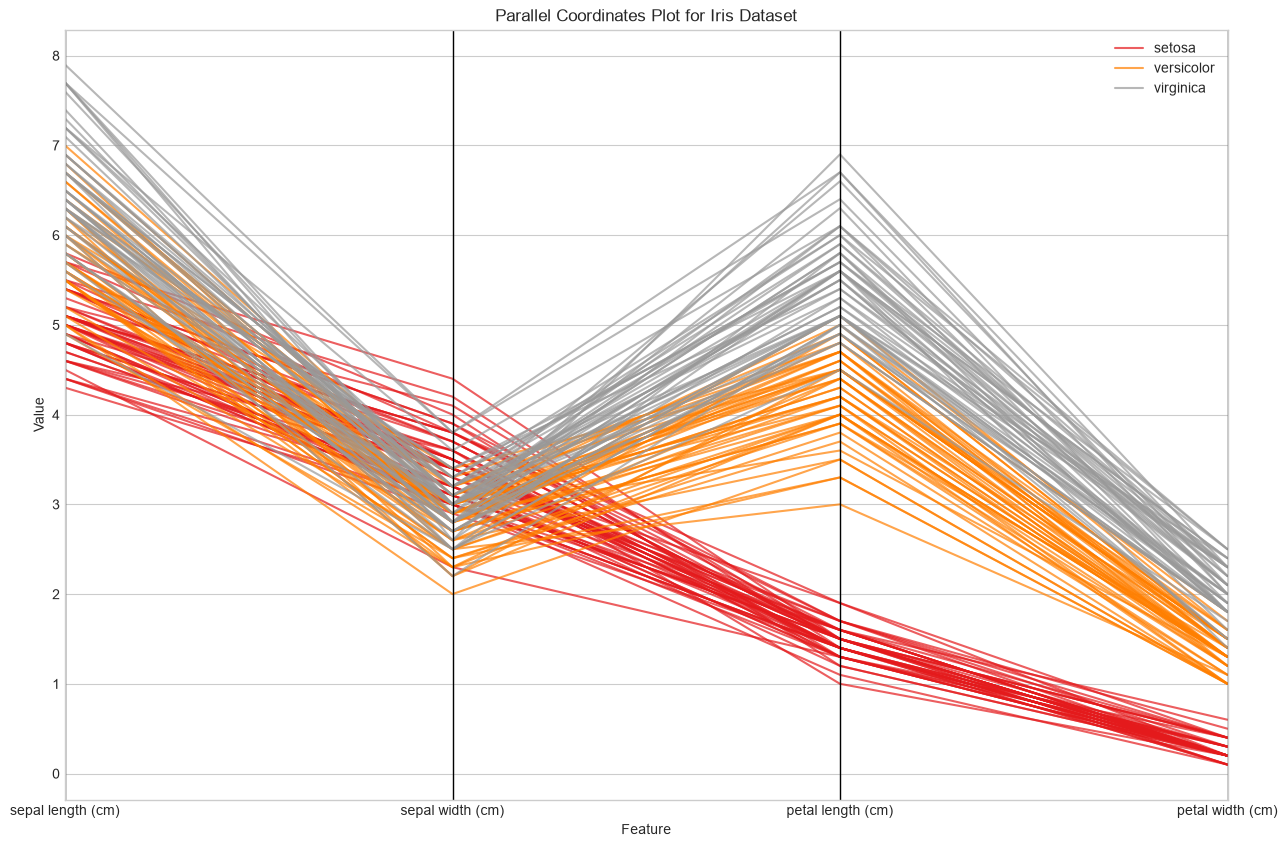

In [ ]:
plt.figure(figsize=(15, 10))
parallel_coordinates(df, class_column="Species", colormap=plt.cm.Set1, alpha=0.7)
plt.title("Parallel Coordinates Plot for Iris Dataset")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.grid(True)
plt.show()

### Encoding label

Kode berikut mengubah label kelas yang berupa teks menjadi angka numerik menggunakan LabelEncoder dari Scikit-Learn.

In [6]:
lab = LabelEncoder()
y = lab.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

### Klasifikasi KNN pada Iris

KNeighborsClassifier digunakan untuk klasifikasi. Akurasi dihitung menggunakan accuracy_score, sedangkan jarak yang digunakan adalah Euclidean.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

In [9]:
result = accuracy_score(y_test, y_pred)
result

0.9666666666666667

## Dataset Athletes

Dataset ini digunakan untuk menentukan apakah seorang atlet masuk draft (yes) atau tidak (no) berdasarkan dua fitur utama:

- speed → kecepatan atlet
- agility → kelincahan atlet

Kolom draft merupakan target/label kelas.

In [ ]:
try:
    df = pd.read_csv('athletes.csv')
except FileNotFoundError:
    csv_text = """id,speed,agility,draft
1,2.5,6,no
2,3.75,8,no
3,2.25,5.5,no
4,3.25,8.25,no
5,2.75,7.5,no
6,4.5,5,no
7,3.5,5.25,no
8,3,3.25,no
9,4,4,no
10,4.25,3.75,no
11,2,2,no
12,5,2.5,no
13,8.25,8.5,no
14,5.75,8.75,yes
15,4.75,6.25,yes
16,5.5,6.75,yes
17,5.25,9.5,yes
18,7,4.25,yes
19,7.5,8,yes
20,7.25,5.75,yes
"""
    df = pd.read_csv(io.StringIO(csv_text))
print(df)

    id  speed  agility draft
0    1   2.50     6.00    no
1    2   3.75     8.00    no
2    3   2.25     5.50    no
3    4   3.25     8.25    no
4    5   2.75     7.50    no
5    6   4.50     5.00    no
6    7   3.50     5.25    no
7    8   3.00     3.25    no
8    9   4.00     4.00    no
9   10   4.25     3.75    no
10  11   2.00     2.00    no
11  12   5.00     2.50    no
12  13   8.25     8.50    no
13  14   5.75     8.75   yes
14  15   4.75     6.25   yes
15  16   5.50     6.75   yes
16  17   5.25     9.50   yes
17  18   7.00     4.25   yes
18  19   7.50     8.00   yes
19  20   7.25     5.75   yes


In [11]:
feature_columns = ['speed', 'agility']
X = df[feature_columns].values
y = df['draft'].values
X

array([[2.5 , 6.  ],
       [3.75, 8.  ],
       [2.25, 5.5 ],
       [3.25, 8.25],
       [2.75, 7.5 ],
       [4.5 , 5.  ],
       [3.5 , 5.25],
       [3.  , 3.25],
       [4.  , 4.  ],
       [4.25, 3.75],
       [2.  , 2.  ],
       [5.  , 2.5 ],
       [8.25, 8.5 ],
       [5.75, 8.75],
       [4.75, 6.25],
       [5.5 , 6.75],
       [5.25, 9.5 ],
       [7.  , 4.25],
       [7.5 , 8.  ],
       [7.25, 5.75]])

In [12]:
y

<StringArray>
[ 'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',
  'no',  'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes']
Length: 20, dtype: str

### Visualisasi data Athletes

Label draft diencode menjadi numerik, lalu warna titik dibuat berdasarkan nilai kelas.

In [ ]:
en = LabelEncoder()
y = en.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

['r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'g' 'g' 'g' 'g' 'g'
 'g' 'g']


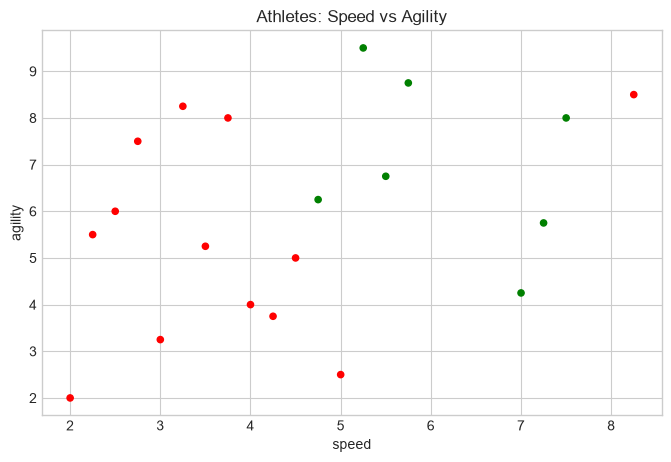

In [14]:
from numpy import where

df['key1'] = y
colors = np.where(df["key1"] == 0, 'r', 'g')
print(colors)

ax = df.plot.scatter(x='speed', y='agility', c=colors, figsize=(8, 5))
ax.set_title('Athletes: Speed vs Agility')
plt.show()

### Split data dan klasifikasi KNN

Sesuai modul, model Athletes menggunakan k=5 dan metrik Euclidean.

In [ ]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 1, 0])

In [16]:
result = accuracy_score(y_test, y_pred)
result

0.75

### Mencari nilai K

Untuk menemukan nilai K yang tepat, beberapa variasi nilai K dicoba dan akurasinya dibandingkan.

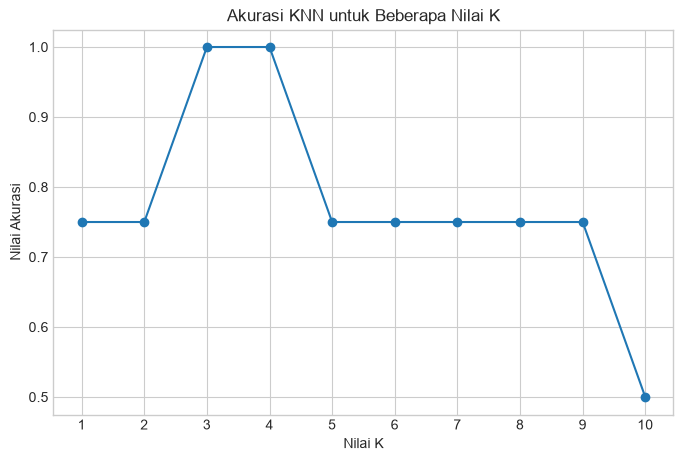

In [17]:
array_k = []
for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    result = accuracy_score(y_test, y_pred)
    array_k.append(result)

plt.figure(figsize=(8, 5))
plt.plot(array_k, marker='o')
plt.ylabel('Nilai Akurasi')
plt.xlabel('Nilai K')
plt.xticks(np.arange(10), ('1','2','3','4','5','6','7','8','9','10'))
plt.title('Akurasi KNN untuk Beberapa Nilai K')
plt.show()